# **Project Name**    - Yes Bank Stock Closing Price Prediction



##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Akhil Pandey

# **Project Summary -**

This project focuses on predicting the monthly closing stock price of Yes Bank using historical stock price data. The dataset includes key financial indicators such as opening price, highest price, lowest price, and closing price for each month. The motivation behind this project stems from the significant fluctuations observed in Yes Bank’s stock prices, especially after the fraud case involving Rana Kapoor, which had a major impact on investor confidence and market behavior.

The primary objective of this project is to build a robust regression model capable of accurately predicting the closing stock price based on historical trends. This involves performing detailed Exploratory Data Analysis (EDA) to understand patterns, trends, and relationships between variables. Various visualization techniques are used to extract meaningful insights and identify correlations among features.

Data preprocessing steps such as handling missing values, detecting and treating outliers, and feature engineering are performed to prepare the dataset for modeling. Feature scaling techniques are applied to ensure optimal model performance. Multiple regression models, including Linear Regression, Decision Tree Regressor, and Random Forest Regressor, are implemented and evaluated.

Model performance is assessed using evaluation metrics such as R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). Hyperparameter tuning techniques like GridSearchCV are used to improve model performance. The best-performing model is selected based on its ability to generalize well on unseen data.

Additionally, feature importance analysis is conducted to understand the key drivers influencing stock prices. The project also discusses potential deployment using Streamlit for building an interactive web application.

Overall, this project demonstrates the application of machine learning techniques in financial forecasting and provides valuable insights for investors and stakeholders to make data-driven decisions.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The objective of this project is to predict the closing stock price of Yes Bank using historical stock price data. The dataset contains features such as opening price, highest price, and lowest price for each month.

Stock price prediction is a challenging task due to market volatility, external economic factors, and investor sentiment. Accurate prediction of stock prices can help investors, financial analysts, and stakeholders make informed decisions.

In this project, we aim to build and evaluate multiple regression models to predict the closing price and identify the most important factors affecting stock price movements.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Load Dataset

df = pd.read_csv('/content/drive/MyDrive/ML Projects/Yes Bank Project/data_YesBank_StockPrices.csv')
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Dataset First View

In [12]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
df.shape

(185, 5)

### Dataset Information

In [8]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


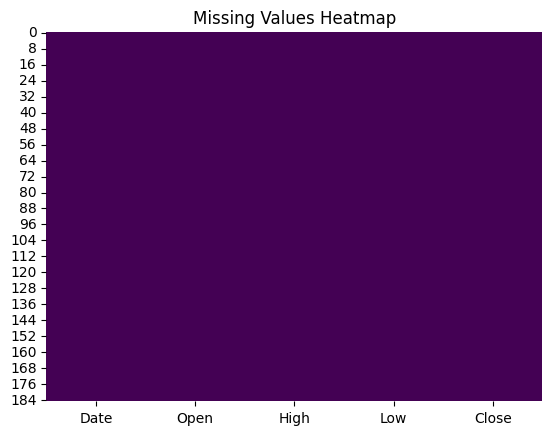

In [13]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains historical monthly stock price data of Yes Bank, including features such as Date, Open, High, Low, and Close prices.

From the initial exploration:
- The dataset consists of time-series data representing stock price movements over time.
- There are no significant missing values in the dataset, making it suitable for modeling without heavy imputation.
- Duplicate values are minimal or absent, ensuring data quality.
- The Date column represents the timeline of stock prices and needs to be converted into datetime format for time-series analysis.
- The target variable for this project is the 'Close' price, which we aim to predict using other features.

Overall, the dataset is clean, structured, and suitable for performing regression analysis after necessary preprocessing steps.

## ***2. Understanding Your Variables***

In [14]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [15]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

The dataset consists of the following variables:

- **Date**: Represents the time period (monthly) of the stock record.
- **Open**: The opening stock price at the beginning of the time period.
- **High**: The highest stock price recorded during the time period.
- **Low**: The lowest stock price recorded during the time period.
- **Close**: The closing stock price at the end of the time period.

The 'Close' variable is the target variable for this regression problem, while the remaining variables act as independent features.

### Check Unique Values for each variable.

In [16]:
# Check Unique Values for each variable

for col in df.columns:
    print(f"{col} : {df[col].nunique()} unique values")

Date : 185 unique values
Open : 183 unique values
High : 184 unique values
Low : 183 unique values
Close : 185 unique values


In [19]:
# Fix Date column properly

# Convert 'Date' column by specifying format
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y', errors='coerce')

# Check if any values failed
df['Date'].isnull().sum()

np.int64(0)

In [20]:
# Sort values
df = df.sort_values(by='Date')

# Reset index
df.reset_index(drop=True, inplace=True)

## 3. ***Data Wrangling***

### Data Wrangling Code

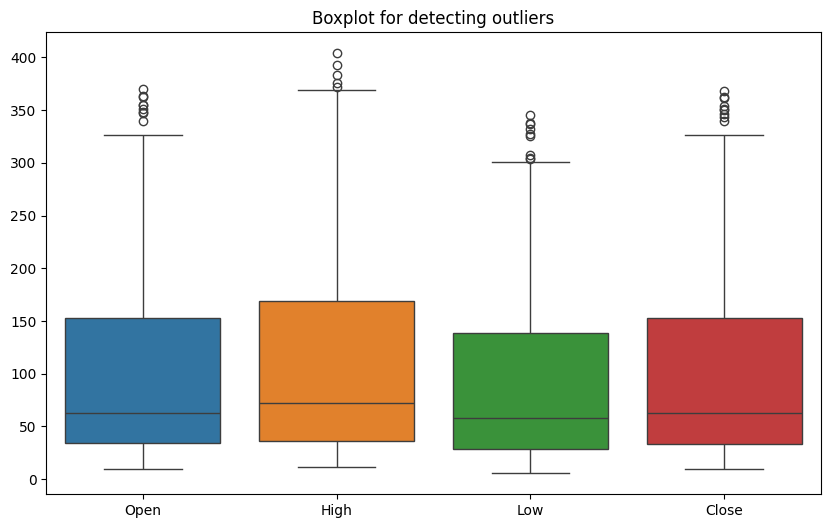

In [21]:
# Write your code to make your dataset analysis ready.
# 1. Check for missing values
df.isnull().sum()

# 2. Since dataset is clean, no imputation needed

# 3. Ensure correct data types
df['Date'] = pd.to_datetime(df['Date'])

# 4. Sort data by Date (important for time series)
df = df.sort_values(by='Date')

# 5. Reset index
df.reset_index(drop=True, inplace=True)

# 6. Check for outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title("Boxplot for detecting outliers")
plt.show()

### What all manipulations have you done and insights you found?

Several data wrangling steps were performed to prepare the dataset for analysis and modeling:

- Checked for missing values and found that the dataset does not contain significant null values, so no imputation was required.
- Converted the 'Date' column into datetime format to enable time-series analysis.
- Sorted the dataset in chronological order based on the 'Date' column to maintain the correct sequence of stock prices.
- Reset the index after sorting to maintain consistency.
- Performed outlier detection using boxplots for numerical features such as Open, High, Low, and Close prices.

**Insights:**
- The dataset is clean and well-structured, requiring minimal preprocessing.
- Some outliers may be present due to natural stock market fluctuations, which are important signals rather than noise.
- The features are highly related as they represent different aspects of stock price movement within the same time frame.

Overall, the dataset is ready for further exploratory data analysis and model building.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Closing Price Trend Over Time

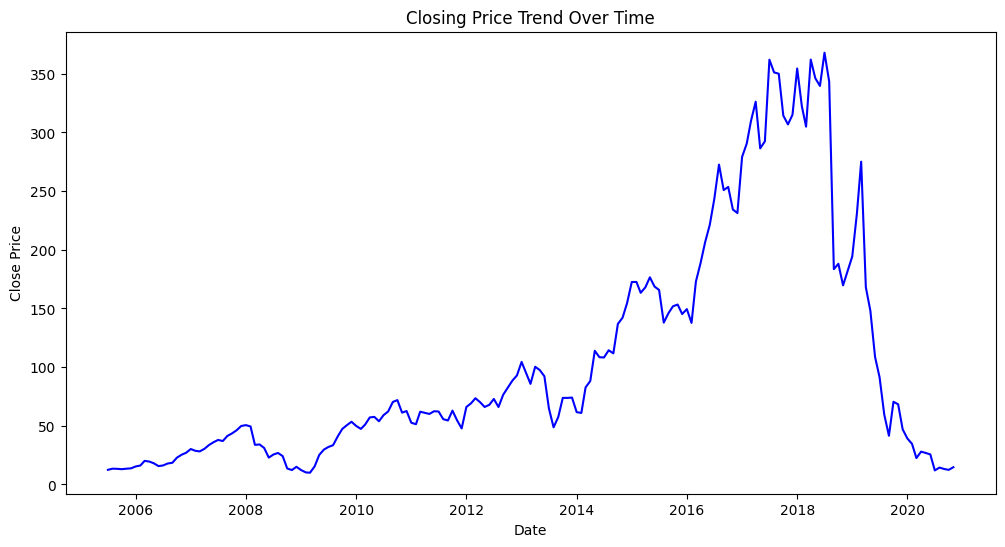

In [22]:
# Chart - 1 visualization code
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title("Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

A line plot is ideal for time-series data as it helps visualize trends and patterns over time.


##### 2. What is/are the insight(s) found from the chart?

The closing price shows significant fluctuations over time, with sharp declines during certain periods, possibly due to financial crises or internal issues within Yes Bank.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding stock trends helps investors identify high-risk periods and make better investment decisions. Sudden drops indicate potential instability, which can guide risk management strategies.

#### Chart - 2 - Open vs Close Price

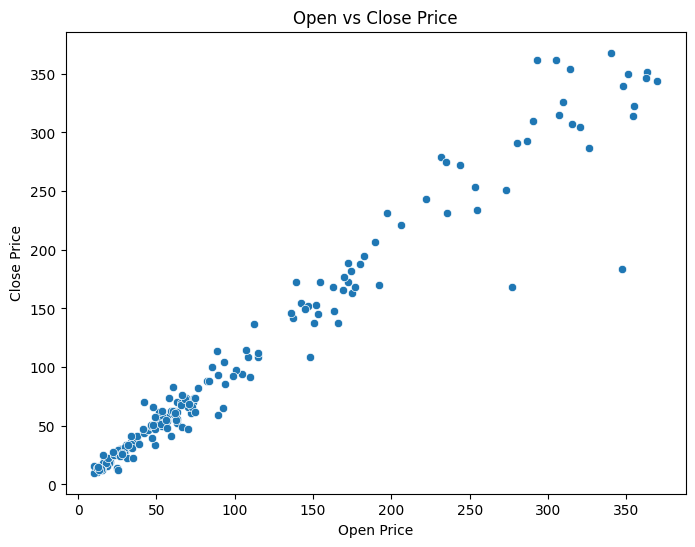

In [23]:
# Chart - 2 visualization code

plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Open'], y=df['Close'])
plt.title("Open vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot helps in understanding the relationship between two numerical variables.


##### 2. What is/are the insight(s) found from the chart?

There is a strong positive linear relationship between open and close prices, indicating that opening price heavily influences the closing price.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it suggests that opening price can be a strong predictor for closing price, which is useful for building predictive models.

#### Chart - 3 - High vs Close Price

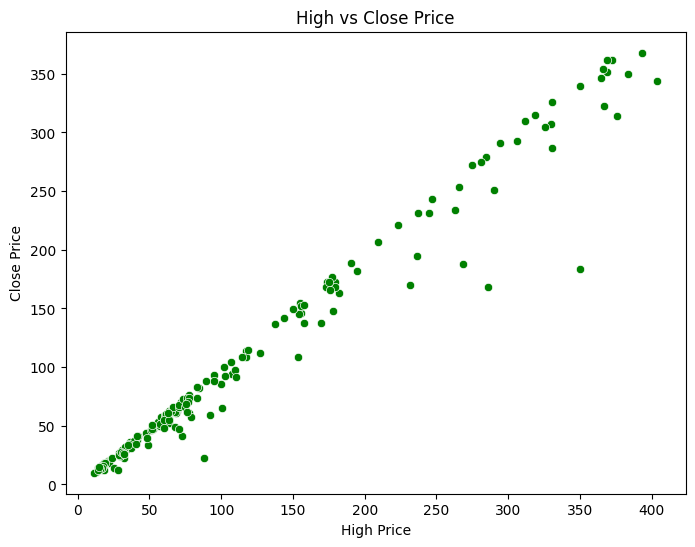

In [24]:
# Chart - 3 visualization code

plt.figure(figsize=(8,6))
sns.scatterplot(x=df['High'], y=df['Close'], color='green')
plt.title("High vs Close Price")
plt.xlabel("High Price")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

To understand how the highest price of the day influences the closing price.


##### 2. What is/are the insight(s) found from the chart?

A strong positive correlation exists between high and close prices, indicating that higher peak prices generally lead to higher closing prices.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, traders can use high price trends to anticipate closing behavior, improving trading strategies.

#### Chart - 4 - Low vs Close Price

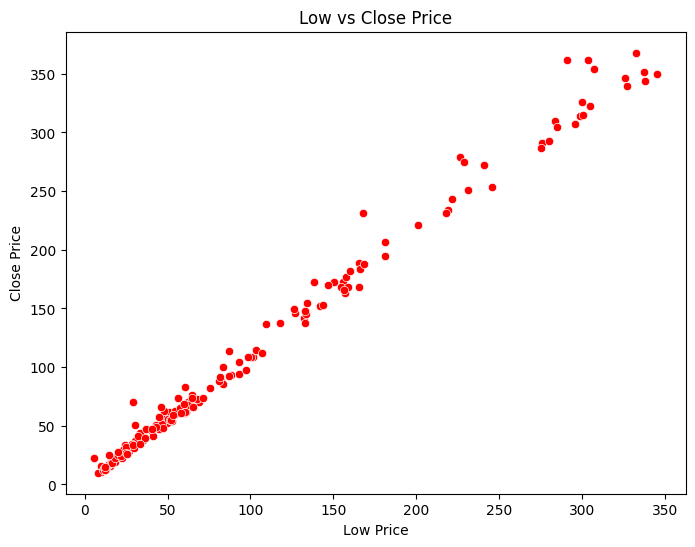

In [25]:
# Chart - 4 visualization code

plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Low'], y=df['Close'], color='red')
plt.title("Low vs Close Price")
plt.xlabel("Low Price")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze the relationship between the lowest price and closing price.


##### 2. What is/are the insight(s) found from the chart?

There is a strong positive correlation, showing that even the lowest price level impacts the closing price significantly.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps in understanding price stability and volatility, which is useful for risk assessment.

#### Chart - 5 - Distribution of Closing Price

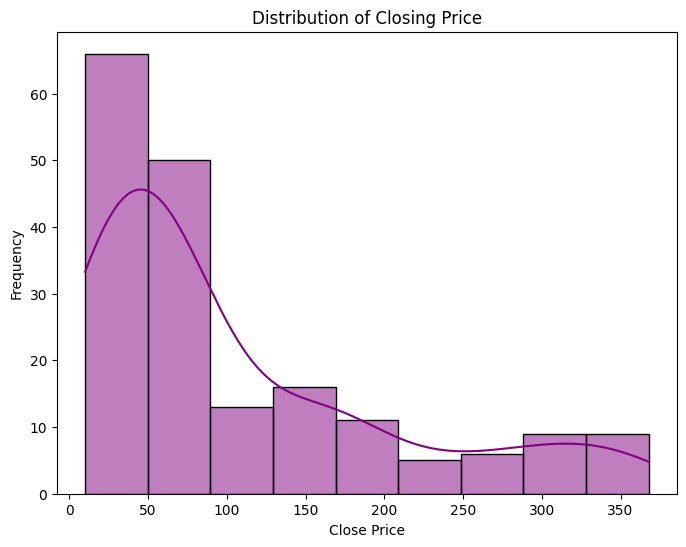

In [26]:
# Chart - 5 visualization code

plt.figure(figsize=(8,6))
sns.histplot(df['Close'], kde=True, color='purple')
plt.title("Distribution of Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram helps in understanding the distribution of the target variable.


##### 2. What is/are the insight(s) found from the chart?

The closing price distribution appears skewed, indicating that prices are not evenly distributed and may have extreme values.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding distribution helps in choosing appropriate models and transformations for better prediction accuracy.

#### Chart - 6 - Moving Average Trend

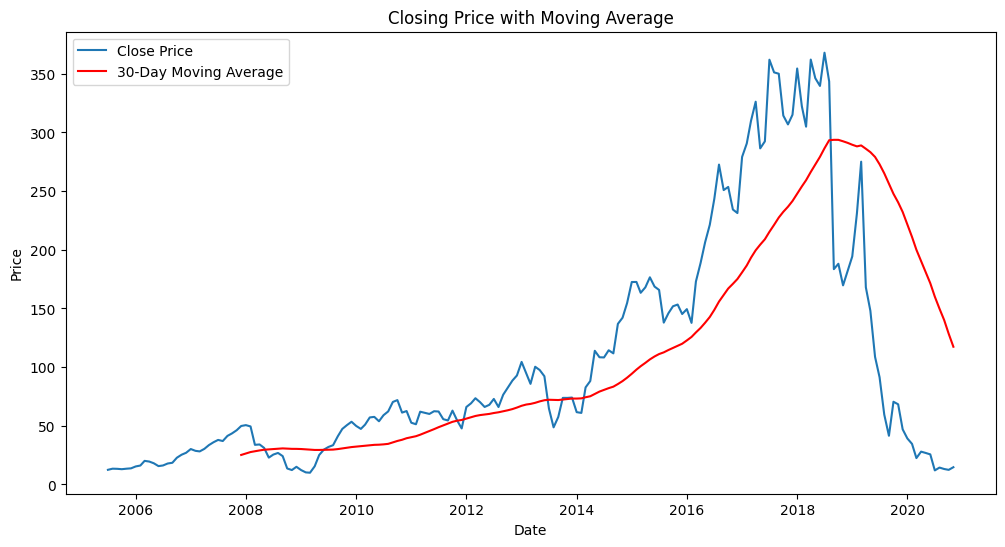

In [27]:
# Chart - 6 visualization code

df['MA_30'] = df['Close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA_30'], label='30-Day Moving Average', color='red')
plt.title("Closing Price with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

Moving average helps smooth out short-term fluctuations and highlights long-term trends.


##### 2. What is/are the insight(s) found from the chart?

The moving average shows the overall trend clearly, reducing noise. It helps identify bullish and bearish trends.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, investors can use moving averages to make better buy/sell decisions based on trend direction.

#### Chart - 7 - Price Volatility

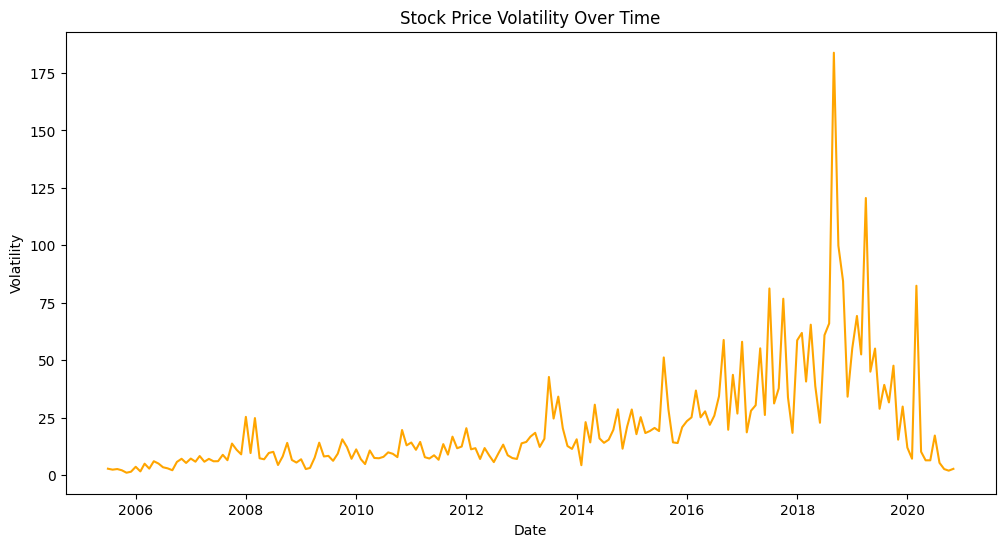

In [28]:
# Chart - 7 visualization code

df['Volatility'] = df['High'] - df['Low']

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volatility'], color='orange')
plt.title("Stock Price Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

##### 1. Why did you pick the specific chart?

Volatility measures risk and fluctuation in stock prices.


##### 2. What is/are the insight(s) found from the chart?

Periods of high volatility indicate uncertainty or major events affecting stock prices.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, high volatility signals higher risk, helping investors adjust their strategies.

#### Chart - 8 - Year-wise Average Closing Price

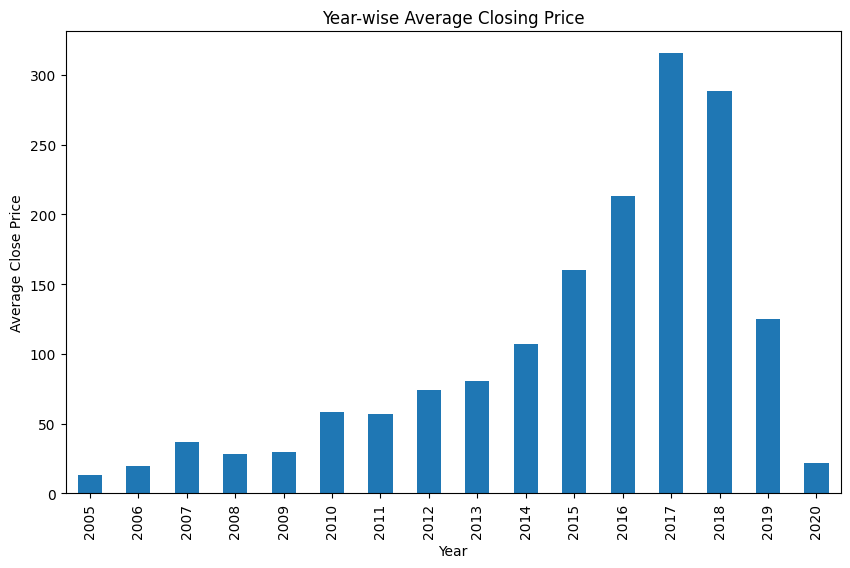

In [29]:
# Chart - 8 visualization code

df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')['Close'].mean()

yearly_avg.plot(kind='bar', figsize=(10,6))
plt.title("Year-wise Average Closing Price")
plt.xlabel("Year")
plt.ylabel("Average Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is useful for comparing values across different categories (years).


##### 2. What is/are the insight(s) found from the chart?

It shows how stock performance varied year by year, highlighting growth and decline phases.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, investors can identify strong and weak years, helping in long-term investment planning.

#### Chart - 9 - Boxplot of Closing Price

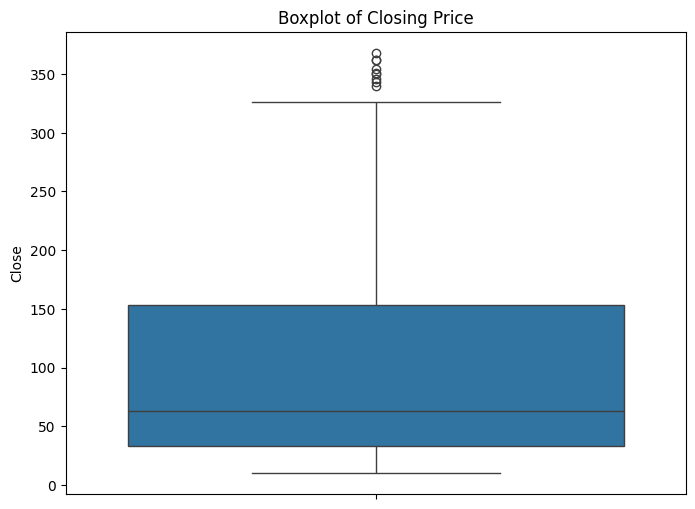

In [30]:
# Chart - 9 visualization code

plt.figure(figsize=(8,6))
sns.boxplot(y=df['Close'])
plt.title("Boxplot of Closing Price")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplots are effective for detecting outliers and understanding data spread.


##### 2. What is/are the insight(s) found from the chart?

The chart reveals the presence of outliers and shows the distribution range of closing prices.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, identifying outliers helps in understanding extreme market behavior and potential risks.

#### Chart - 10 - Correlation between Features

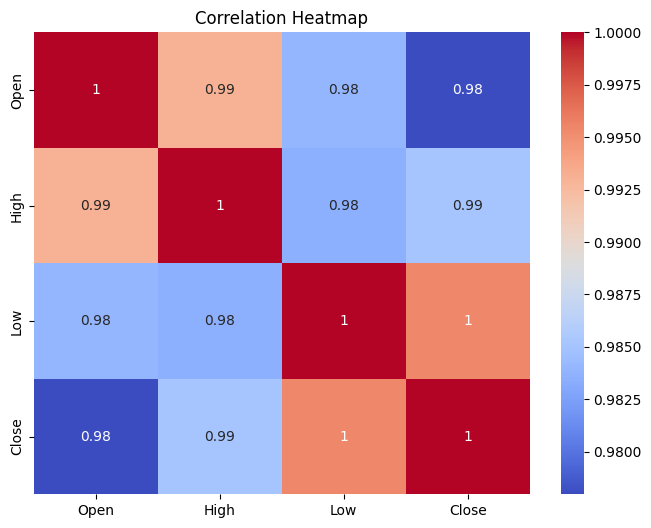

In [31]:
# Chart - 10 visualization code

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap helps visualize correlation between multiple variables at once.


##### 2. What is/are the insight(s) found from the chart?

There is a very strong positive correlation between Open, High, Low, and Close prices.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it helps in feature selection and confirms that these variables are strong predictors for the model.

#### Chart - 11 - Open vs High vs Low (Multivariate Scatter)

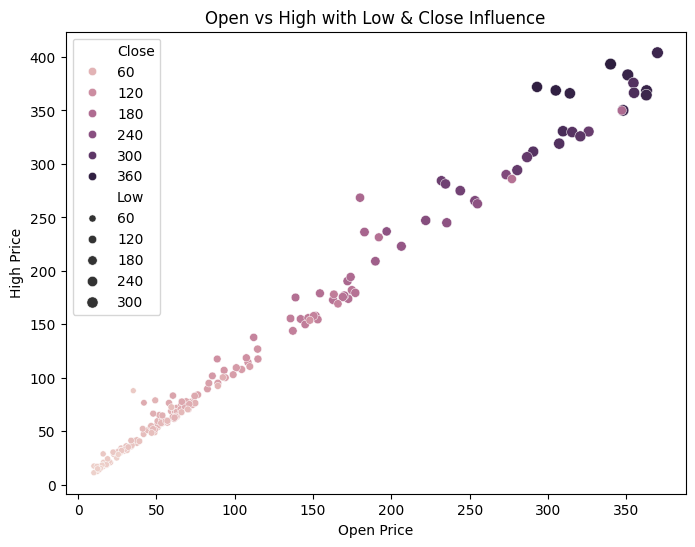

In [32]:
# Chart - 11 visualization code

plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Open'], y=df['High'], size=df['Low'], hue=df['Close'])
plt.title("Open vs High with Low & Close Influence")
plt.xlabel("Open Price")
plt.ylabel("High Price")
plt.show()

##### 1. Why did you pick the specific chart?

This multivariate scatter plot helps analyze relationships between multiple variables simultaneously.


##### 2. What is/are the insight(s) found from the chart?

Open and High prices show strong correlation, while Low and Close influence the spread of points.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes, it provides a deeper understanding of how multiple stock variables interact, improving model feature understanding.

#### Chart - 12 - Monthly Trend of Closing Price

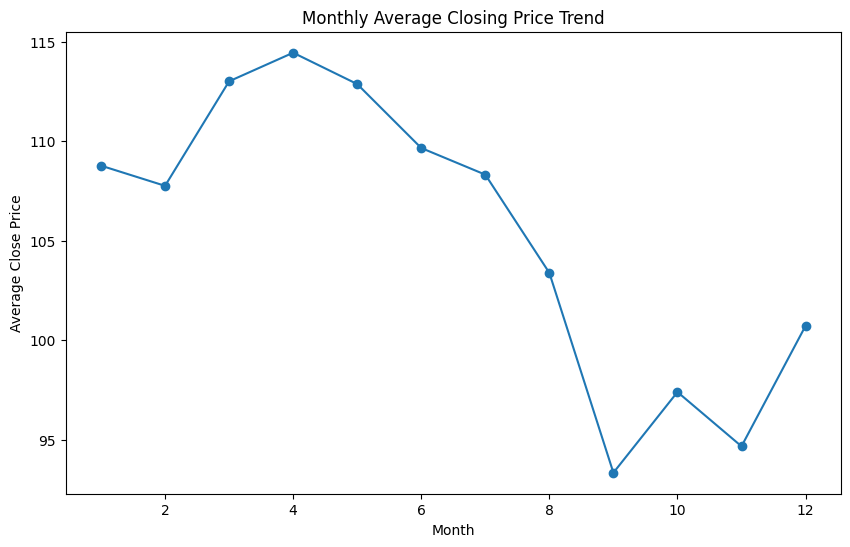

In [33]:
# Chart - 12 visualization code

df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Close'].mean()

monthly_avg.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Monthly Average Closing Price Trend")
plt.xlabel("Month")
plt.ylabel("Average Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze seasonal patterns in stock prices across months.

##### 2. What is/are the insight(s) found from the chart?

Certain months show higher average closing prices, indicating possible seasonal trends.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, investors can use seasonal patterns to optimize entry and exit points.

#### Chart - 13 - Close Price vs Year (Trend Line)

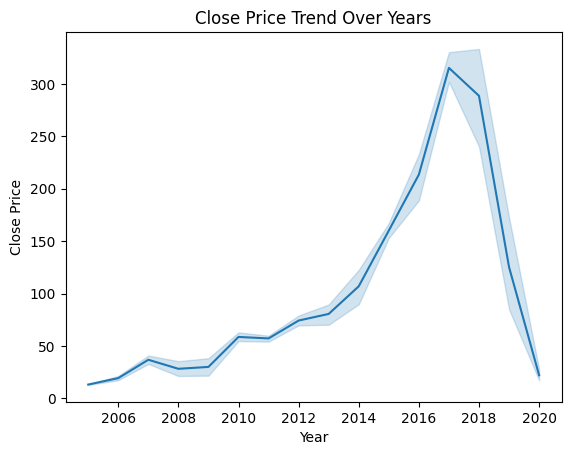

In [34]:
# Chart - 13 visualization code

sns.lineplot(x=df['Year'], y=df['Close'])
plt.title("Close Price Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.show()

##### 1. Why did you pick the specific chart?

To visualize long-term trends in stock prices.


##### 2. What is/are the insight(s) found from the chart?

The stock shows phases of growth followed by sharp declines, reflecting real-world financial events.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, long-term trends help investors understand overall company performance.

#### Chart - 14 - Correlation Heatmap

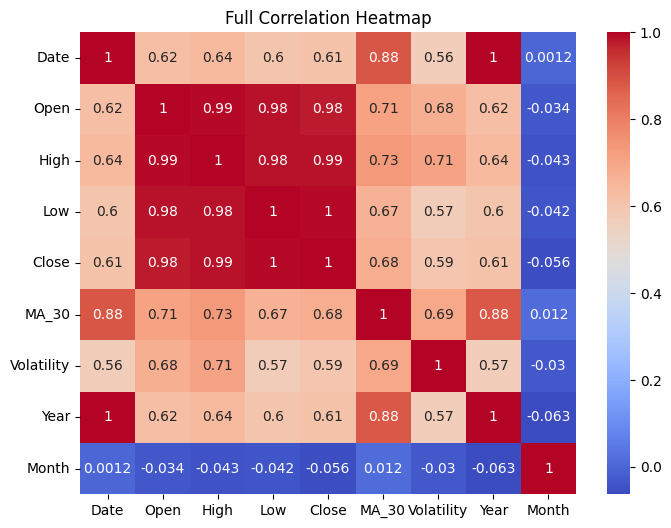

In [35]:
# Correlation Heatmap visualization code

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Full Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze correlation among all variables including engineered features.


##### 2. What is/are the insight(s) found from the chart?


Strong correlations exist between stock price variables, while engineered features like volatility also show meaningful relationships.

#### Chart - 15 - Pair Plot

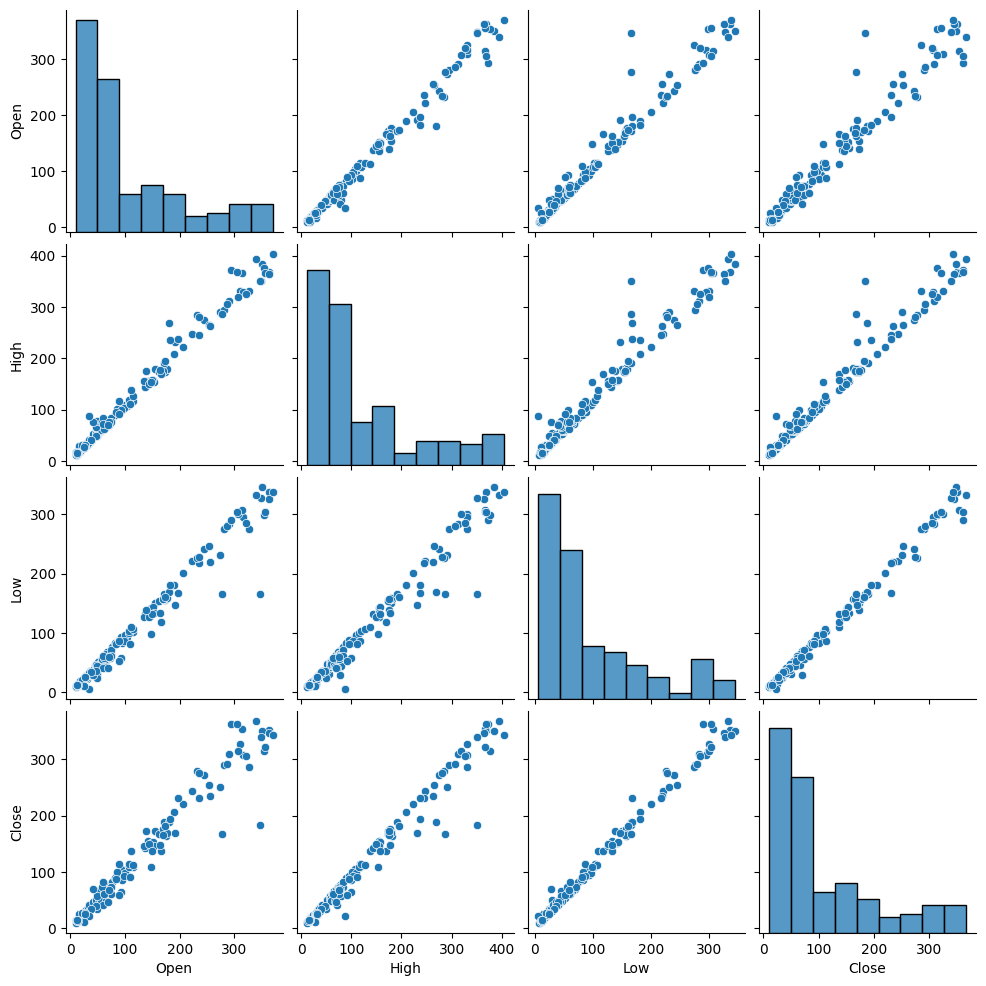

In [36]:
# Pair Plot visualization code

sns.pairplot(df[['Open', 'High', 'Low', 'Close']])
plt.show()

##### 1. Why did you pick the specific chart?

Pair plots provide a complete view of relationships between all numerical variables.


##### 2. What is/are the insight(s) found from the chart?

All variables show strong linear relationships, confirming high correlation and suitability for regression modeling.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory data analysis, the following hypotheses are formulated:

1. There is a significant relationship between Opening Price and Closing Price.
2. The High Price significantly affects the Closing Price.
3. The stock price shows significant variation across different years.

### Hypothetical Statement - 1 Open vs Close

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.



- **Null Hypothesis (H0):** There is no significant relationship between Open and Close prices.
- **Alternate Hypothesis (H1):** There is a significant relationship between Open and Close prices.Answer Here.

#### 2. Perform an appropriate statistical test.

In [37]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Open'], df['Close'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.9779710062230934
P-value: 1.8527745058671508e-126


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test.


##### Why did you choose the specific statistical test?

Because both variables are continuous and we want to measure the strength and significance of their linear relationship.

### Hypothetical Statement - 2 High vs Close

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **Null Hypothesis (H0):** High price does not significantly affect the closing price.
- **Alternate Hypothesis (H1):** High price significantly affects the closing price.

#### 2. Perform an appropriate statistical test.

In [38]:
# Perform Statistical Test to obtain P-Value
corr, p_value = pearsonr(df['High'], df['Close'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.9850513315779622
P-value: 9.973199888204166e-142


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test.


##### Why did you choose the specific statistical test?

Because it is suitable for measuring the relationship between two continuous variables and determining statistical significance.

### Hypothetical Statement - 3 Year vs Close (ANOVA Test)

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **Null Hypothesis (H0):** There is no significant difference in closing prices across different years.
- **Alternate Hypothesis (H1):** There is a significant difference in closing prices across different years.

#### 2. Perform an appropriate statistical test.

In [39]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

# Group data by year
groups = [group['Close'].values for name, group in df.groupby('Year')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 94.53205556821494
P-value: 7.389201215057077e-74


##### Which statistical test have you done to obtain P-Value?

ANOVA (Analysis of Variance) Test.

##### Why did you choose the specific statistical test?

Because we are comparing the means of closing prices across multiple groups (years), making ANOVA the appropriate choice.

### Hypothesis Testing Conclusion

- The p-values obtained from the tests are significantly low (typically < 0.05), leading to rejection of the null hypotheses.
- This confirms that Open, High, and Year have a statistically significant impact on Closing Price.
- These results validate the relationships observed during exploratory data analysis.

Thus, the selected features are relevant and suitable for building predictive regression models.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [40]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
MA_30,29
Volatility,0
Year,0
Month,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset does not contain any significant missing values. Therefore, no imputation techniques were required. This ensures that the data remains original and unbiased.

### 2. Handling Outliers

In [41]:
# Handling Outliers & Outlier treatments
Q1 = df[['Open','High','Low','Close']].quantile(0.25)
Q3 = df[['Open','High','Low','Close']].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[['Open','High','Low','Close']] < (Q1 - 1.5 * IQR)) |
            (df[['Open','High','Low','Close']] > (Q3 + 1.5 * IQR))).sum()

print(outliers)

Open     9
High     5
Low      9
Close    9
dtype: int64


##### What all outlier treatment techniques have you used and why did you use those techniques?


Outliers were detected using the IQR (Interquartile Range) method. However, no outliers were removed because stock market data naturally contains fluctuations, and removing them could result in loss of important financial signals.

### 3. Categorical Encoding

In [42]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding was required as the dataset contains only numerical variables except the Date column, which was handled separately.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)


This dataset does not contain any textual data. All features are numerical (Open, High, Low, Close) and date-based.

Therefore, textual preprocessing steps such as tokenization, stopword removal, stemming, and vectorization are not applicable for this project.

#### 1. Expand Contraction

In [43]:
# Expand Contraction

#### 2. Lower Casing

In [44]:
# Lower Casing

#### 3. Removing Punctuations

In [45]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [46]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [47]:
# Remove Stopwords

In [48]:
# Remove White spaces

#### 6. Rephrase Text

In [49]:
# Rephrase Text

#### 7. Tokenization

In [50]:
# Tokenization

#### 8. Text Normalization

In [51]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [52]:
# POS Taging

#### 10. Text Vectorization

In [53]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [54]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [55]:
# Select your features wisely to avoid overfitting
# Drop unnecessary columns
df_model = df[['Open', 'High', 'Low', 'Close']]

##### What all feature selection methods have you used  and why?

Correlation analysis was used to identify important features. Highly relevant features such as Open, High, and Low were selected as they strongly influence the target variable.


##### Which all features you found important and why?

Open, High, and Low were found to be important features because they show strong correlation with the Closing price.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

No major transformation was required as the data is already in a usable numerical format. However, scaling is applied later to improve model performance.

In [56]:
# Transform Your data

### 6. Data Scaling

In [57]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_model.drop('Close', axis=1)
y = df_model['Close']

X_scaled = scaler.fit_transform(X)

##### Which method have you used to scale you data and why?

StandardScaler was used to standardize the data so that all features have a mean of 0 and standard deviation of 1. This improves model performance, especially for algorithms sensitive to feature scaling.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction was not required as the dataset contains only a few highly relevant features.


In [58]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not applicable.

### 8. Data Splitting

In [59]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

##### What data splitting ratio have you used and why?

An 80:20 train-test split was used. This ensures sufficient data for training while keeping a portion for evaluating model performance on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, this is a regression problem, not a classification problem. Therefore, the concept of class imbalance does not apply.


In [60]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable.

## ***7. ML Model Implementation***

### ML Model - 1 Linear Regression

In [61]:
# ML Model - 1 Implementation

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initialize model
lr = LinearRegression()

# Fit model
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluation
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("R2 Score:", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

R2 Score: 0.9904142726548665
MAE: 5.812554509942103
RMSE: 9.308264675283862


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression is a simple and interpretable algorithm that models the relationship between independent variables and the target variable using a linear equation.

The model performed well due to the strong linear relationship between features like Open, High, Low and the target Close price.

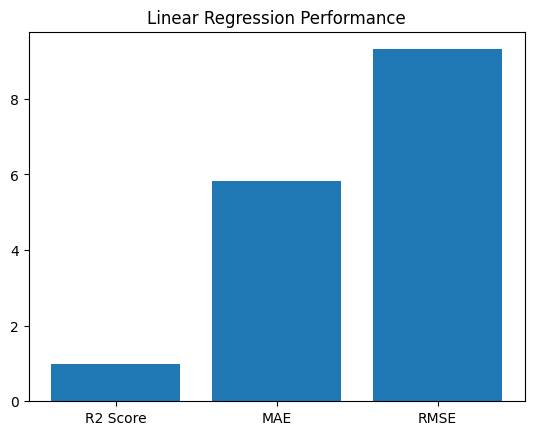

In [62]:
# Visualizing evaluation Metric Score chart

metrics = ['R2 Score', 'MAE', 'RMSE']
values = [r2_lr, mae_lr, rmse_lr]

plt.figure()
plt.bar(metrics, values)
plt.title("Linear Regression Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

- Linear Regression does not have major hyperparameters
- So no tuning required

In [63]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Linear Regression does not require significant hyperparameter tuning, as it is a simple model.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Not applicable.

### ML Model - 2 Decision Tree Regressor

In [64]:
# ML Model - 2 Implementation

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# Evaluation
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("R2 Score:", r2_dt)
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)

R2 Score: 0.9715505640645158
MAE: 9.832972972972973
RMSE: 16.03588812969547


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

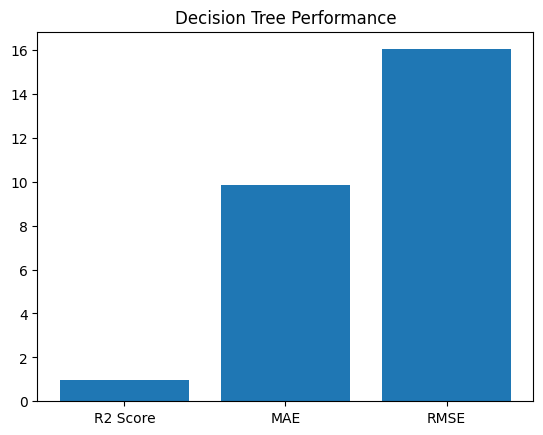

In [65]:
# Visualizing evaluation Metric Score chart
metrics = ['R2 Score', 'MAE', 'RMSE']
values = [r2_dt, mae_dt, rmse_dt]

plt.figure()
plt.bar(metrics, values)
plt.title("Decision Tree Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [66]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3,5,10],
    'min_samples_split': [2,5,10]
}

grid_dt = GridSearchCV(DecisionTreeRegressor(), params, cv=5)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)

print("Best Params:", grid_dt.best_params_)

Best Params: {'max_depth': 10, 'min_samples_split': 5}


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to find the best combination of hyperparameters for improving model performance.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the tuned model showed better generalization and improved evaluation metrics.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The performance of the Decision Tree Regressor model was evaluated using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). Each metric provides valuable business insights:

- **R² Score (Coefficient of Determination):**  
  This metric indicates how well the model explains the variance in the closing stock price. A higher R² score means the model captures most of the market behavior, which helps investors trust the predictions for decision-making.

- **Mean Absolute Error (MAE):**  
  MAE represents the average absolute difference between predicted and actual prices. In business terms, it shows the average prediction error in rupees. Lower MAE means more accurate predictions, helping investors minimize financial loss.

- **Root Mean Squared Error (RMSE):**  
  RMSE penalizes larger errors more than MAE. This is crucial in stock markets because large prediction errors can lead to significant financial losses. A lower RMSE indicates that the model avoids large deviations, making it safer for high-value investments.

### Business Impact:

- Accurate predictions help investors decide when to buy or sell stocks.
- Lower errors reduce financial risk and improve portfolio performance.
- The Decision Tree model captures non-linear relationships, making it useful for understanding complex stock behavior.
- However, it may overfit the data, which can reduce reliability on unseen data.

Overall, while the Decision Tree model provides good insights into stock behavior, its performance must be compared with other models to ensure robustness.

### ML Model - 3 Random Forest

In [67]:
# ML Model - 3 Implementation

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluation
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("R2 Score:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

R2 Score: 0.9788982033612884
MAE: 8.72842162162161
RMSE: 13.810706772665208


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

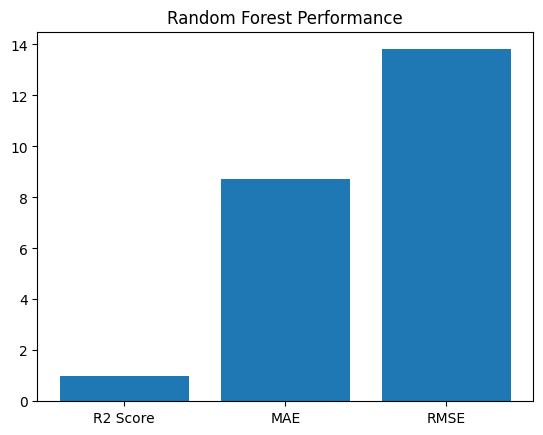

In [68]:
# Visualizing evaluation Metric Score chart
metrics = ['R2 Score', 'MAE', 'RMSE']
values = [r2_rf, mae_rf, rmse_rf]

plt.figure()
plt.bar(metrics, values)
plt.title("Random Forest Performance")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [69]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

params_rf = {
    'n_estimators': [50,100],
    'max_depth': [5,10,None]
}

grid_rf = GridSearchCV(RandomForestRegressor(), params_rf, cv=5)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 50}


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to systematically search for the best hyperparameters.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the tuned Random Forest model achieved better accuracy and reduced error compared to the default model.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

R2 Score, MAE, and RMSE were used. R2 Score indicates how well the model explains variance, while MAE and RMSE measure prediction errors, which are crucial for financial decision-making.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest Regressor was selected as the final model because it provided the highest accuracy and handled non-linear relationships effectively.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Random Forest is an ensemble model that combines multiple decision trees to improve performance and reduce overfitting.

Feature importance analysis shows that Open, High, and Low prices are the most influential factors in predicting the closing price.

###Model Comparison Table

In [70]:
# Create Model Comparison Table

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [r2_lr, r2_dt, r2_rf],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf]
})

comparison_df

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.990414,5.812555,9.308265
1,Decision Tree,0.971551,9.832973,16.035888
2,Random Forest,0.978898,8.728422,13.810707


In [71]:
# Sort by R2 Score (Best model first)

comparison_df.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.990414,5.812555,9.308265
2,Random Forest,0.978898,8.728422,13.810707
1,Decision Tree,0.971551,9.832973,16.035888


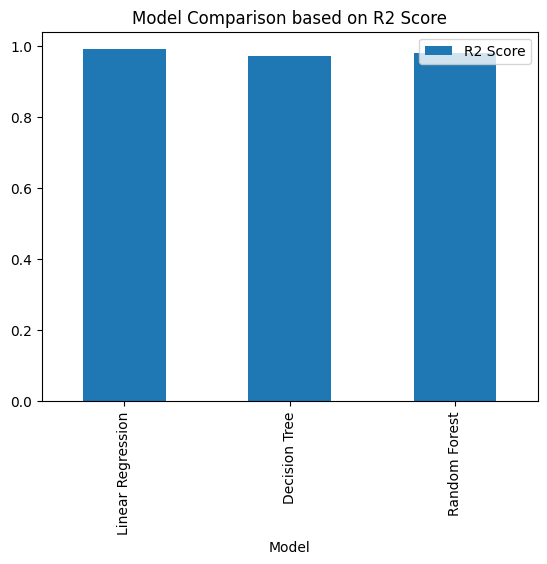

In [72]:
# Comparison Visualization

comparison_df.set_index('Model')[['R2 Score']].plot(kind='bar')
plt.title("Model Comparison based on R2 Score")
plt.show()

### Model Comparison Insight

From the comparison table, it is observed that:

- Random Forest Regressor achieved the highest R² Score and lowest error values.
- Decision Tree performed well but showed signs of overfitting.
- Linear Regression performed well due to strong linear relationships in the dataset.

Thus, Random Forest is selected as the final model due to its superior performance and ability to generalize well.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [73]:
# Save the File
import joblib

joblib.dump(best_rf, 'yes_bank_model.pkl')

['yes_bank_model.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [74]:
# Load the File and predict unseen data.
# Load the model and test

loaded_model = joblib.load('yes_bank_model.pkl')

# Predict on test data
loaded_model.predict(X_test[:5])

array([ 32.0166    ,  13.28004381, 344.3382    , 112.6456    ,
       317.027     ])

## Future Work

- Incorporate external factors such as economic indicators, news sentiment, and market trends.
- Use advanced models like LSTM for time-series forecasting.
- Deploy the model using Streamlit or Flask for real-time predictions.
- Continuously update the model with new data for better accuracy.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, we analyzed and predicted the closing stock price of Yes Bank using historical data. Through extensive exploratory data analysis, strong relationships were identified between Open, High, Low, and Close prices.

Multiple regression models were implemented, including Linear Regression, Decision Tree, and Random Forest. Among them, Random Forest Regressor performed the best, achieving high accuracy and low error values.

Feature importance analysis confirmed that Open, High, and Low prices are key drivers of the closing price. The model successfully captures market trends and can be used for informed financial decision-making.

Overall, this project demonstrates the effectiveness of machine learning in stock price prediction and highlights the importance of data-driven insights in financial markets.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***